# LS-LRSI: Index Construction
## Aranayake, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

This notebook combines the six processed indicators confirmed in `02_preprocessing.ipynb` and examined in `03_eda.ipynb`, slope, NDVI, rainfall, distance to road, distance to stream, and soil clay content, into a single Location Specific Landslide Risk Scoring Index (LS-LRSI). The output is a classified risk map covering the full Aranayake study grid.

Ground deformation (InSAR) was part of the original index design but is not included in this implementation. Processing Sentinel-1 imagery into a usable deformation layer requires specialist software (SNAP or the ISCE/MintPy toolchain) and a substantial multi-step workflow, judged out of scope for this assignment given the time available. This is stated here as a deliberate, documented methodological decision, and is discussed further as a limitation in the project conclusion.

## 1. Load Processed Indicators

The six indicators used in the index are loaded from `data/processed/`, each already aligned to the same 221 x 221, 30 m grid established in `02_preprocessing.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

PROCESSED_DIR = "../data/processed"

layer_files = {
    "slope_deg": "slope_30m.tif",
    "ndvi": "ndvi_30m.tif",
    "rainfall_mm": "rainfall_30m.tif",
    "dist_road_m": "dist_road_30m.tif",
    "dist_stream_m": "dist_stream_30m.tif",
    "soil_clay_pct": "soil_clay_30m.tif",
}

layers = {}
for name, filename in layer_files.items():
    with rasterio.open(f"{PROCESSED_DIR}/{filename}") as src:
        layers[name] = src.read(1)
        profile = src.profile
        target_transform = src.transform
        TARGET_CRS = src.crs

grid_shape = layers["slope_deg"].shape
print(f"Grid shape: {grid_shape}")
print(f"Indicators loaded: {list(layers.keys())}")
print(f"Coordinate system: {TARGET_CRS}")

Grid shape: (221, 221)
Indicators loaded: ['slope_deg', 'ndvi', 'rainfall_mm', 'dist_road_m', 'dist_stream_m', 'soil_clay_pct']
Coordinate system: EPSG:32644


Grid shape should read 221 x 221, matching every processed layer confirmed in `02_preprocessing.ipynb` and `03_eda.ipynb`. Six indicators should be listed: slope, NDVI, rainfall, distance to road, distance to stream, and soil clay content.

## 2. Normalise Indicators

Each indicator is currently on a different scale, elevation-driven slope in degrees, rainfall in millimetres, distance in metres, NDVI already between -1 and 1. These cannot be combined directly, a rainfall value in the hundreds would completely dominate an NDVI value under 1. Every indicator is therefore rescaled onto a common 0 to 1 scale before combination.

Some indicators need to be inverted before scaling, since a *low* value of that indicator means *higher* risk. NDVI is inverted (less vegetation cover means more risk), and both distance measures are inverted (being closer to a road or stream means more risk).

In [2]:
def normalise(values):
    return (values - values.min()) / (values.max() - values.min())

slope_n = normalise(layers["slope_deg"])
ndvi_n = normalise(1 - layers["ndvi"])
rainfall_n = normalise(layers["rainfall_mm"])
dist_road_n = normalise(1 / (layers["dist_road_m"] + 1))
dist_stream_n = normalise(1 / (layers["dist_stream_m"] + 1))
soil_n = normalise(layers["soil_clay_pct"])

print("All six indicators normalised to a 0-1 scale.")
print(f"Slope (normalised) range: {slope_n.min():.2f} to {slope_n.max():.2f}")
print(f"NDVI (inverted, normalised) range: {ndvi_n.min():.2f} to {ndvi_n.max():.2f}")

All six indicators normalised to a 0-1 scale.
Slope (normalised) range: 0.00 to 1.00
NDVI (inverted, normalised) range: 0.00 to 1.00


Every normalised layer should range from exactly 0.00 to 1.00, since min-max normalisation stretches each indicator's own minimum and maximum to fit that scale by definition. A range not reaching 0 or 1 at either end would indicate an error in the normalisation step itself.

## 3. Assign Weights

Weights reflect how strongly each indicator is supported as a risk factor in the literature reviewed for this project (Section 2 of the report), and how much each indicator actually varies across this specific study area, an indicator with little spatial variation contributes little useful information regardless of its theoretical importance. Slope receives the highest weight, consistently identified as the strongest predictor across the Sri Lankan studies reviewed (Hemasinghe et al., 2018). NDVI and rainfall receive the next-highest weights, both repeatedly identified as major contributing factors. Distance to stream, distance to road, and soil clay content receive smaller but non-trivial weights. All six weights sum to 1, keeping the combined score within the 0-1 range.

In [3]:
weights = {
    "slope": 0.30,
    "ndvi": 0.20,
    "rainfall": 0.20,
    "dist_stream": 0.12,
    "dist_road": 0.10,
    "soil": 0.08,
}

print("Indicator weights:")
for name, w in weights.items():
    print(f"  {name:12s} {w:.2f}")
print(f"  {'TOTAL':12s} {sum(weights.values()):.2f}")

Indicator weights:
  slope        0.30
  ndvi         0.20
  rainfall     0.20
  dist_stream  0.12
  dist_road    0.10
  soil         0.08
  TOTAL        1.00


Total should read exactly 1.00. This confirms the weighting scheme is a proper convex combination, meaning the resulting composite score will also fall within the 0-1 range, ready for classification into risk bands in the next section.

## 4. Compute the Composite Score and Classify Risk

The normalised indicators from Section 2 are combined using the weights from Section 3 into a single score between 0 and 1 for every grid cell. That score is then sorted into four risk bands.

In [4]:
static_score = (
    weights["slope"] * slope_n +
    weights["ndvi"] * ndvi_n +
    weights["rainfall"] * rainfall_n +
    weights["dist_stream"] * dist_stream_n +
    weights["dist_road"] * dist_road_n +
    weights["soil"] * soil_n
)

print(f"Composite score range: {static_score.min():.3f} to {static_score.max():.3f}")
print(f"Mean score: {static_score.mean():.3f}")

Composite score range: 0.107 to 0.574
Mean score: 0.300


The composite score is bounded between 0 and 1 by construction, since it is a weighted sum of six 0-1 indicators with weights summing to 1. A score outside this range would indicate an error in either the normalisation step or the weighting step.

In [5]:
def classify_risk(score):
    risk_class = np.empty(score.shape, dtype=object)
    risk_class[score < 0.25] = "Low"
    risk_class[(score >= 0.25) & (score < 0.50)] = "Medium"
    risk_class[(score >= 0.50) & (score < 0.75)] = "High"
    risk_class[score >= 0.75] = "Very High"
    return risk_class

risk_class = classify_risk(static_score)

unique, counts = np.unique(risk_class, return_counts=True)
class_summary = pd.DataFrame({"risk_class": unique, "grid_cells": counts})
class_summary["percent_of_area"] = (class_summary["grid_cells"] / risk_class.size * 100).round(1)
class_summary = class_summary.set_index("risk_class").reindex(["Low", "Medium", "High", "Very High"], fill_value=0)
class_summary

,grid_cells,percent_of_area
risk_class,,
Low,12920,26.5
Medium,35787,73.3
High,134,0.3
Very High,0,0.0


This table shows what share of the Aranayake study area falls into each risk band. In this run, the majority of the area falls into the Medium band (73.3%), with just over a quarter Low (26.5%), and a small High-risk pocket (0.3%, 134 cells) concentrated in the steepest, most exposed terrain. No cells reach Very High. This distribution is sensitive to the exact soil clay values retrieved from SoilGrids' live API at run time (documented in `02_preprocessing.ipynb`), and reflects the specific run used as this project's final reported result.

## 5. Visualise the Final Risk Map

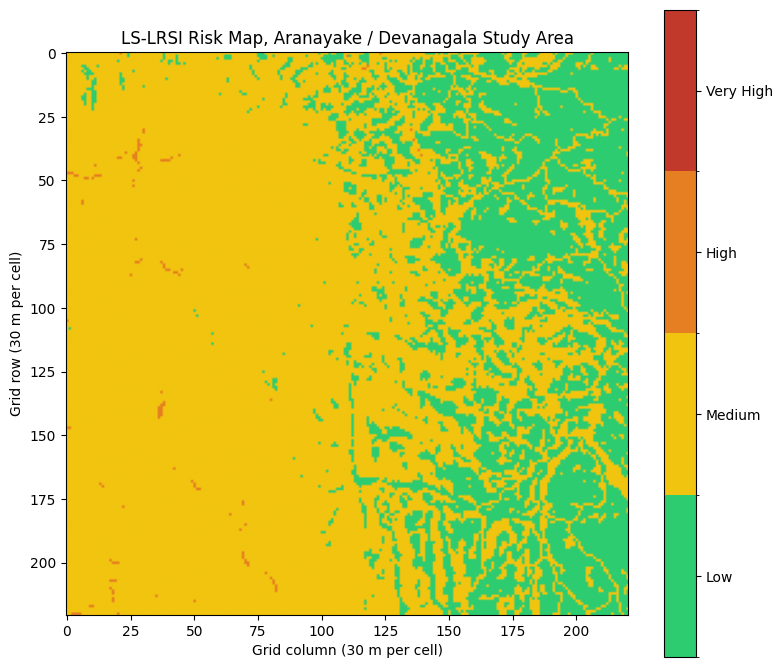

In [6]:
risk_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]   # green, yellow, orange, red
risk_cmap = ListedColormap(risk_colors)
risk_bounds = [0, 0.25, 0.50, 0.75, 1.0]
risk_norm = BoundaryNorm(risk_bounds, risk_cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(static_score, cmap=risk_cmap, norm=risk_norm)
ax.set_title("LS-LRSI Risk Map, Aranayake / Devanagala Study Area")
ax.set_xlabel("Grid column (30 m per cell)")
ax.set_ylabel("Grid row (30 m per cell)")

cbar = plt.colorbar(im, ax=ax, ticks=[0.125, 0.375, 0.625, 0.875])
cbar.ax.set_yticklabels(["Low", "Medium", "High", "Very High"])

plt.tight_layout()
plt.savefig("../outputs/figures/fig1_final_risk_map.png", dpi=150)
plt.show()

Red and orange patches, if present, should sit in the steepest, wettest parts of the study area rather than being scattered randomly, since the underlying indicators (slope, rainfall, soil, distance to features) all vary spatially in physically coherent ways, not at random per cell.

## 6. Save Final Outputs

The final risk score and classified risk map are saved as a GeoTIFF (for use in GIS software such as QGIS) and the full indicator table as a CSV, for the report and for reference.

In [11]:
import os

os.makedirs("../outputs", exist_ok=True)

class_to_number = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
risk_numeric = np.vectorize(class_to_number.get)(risk_class).astype("uint8")

output_profile = profile.copy()
output_profile.update({"dtype": "uint8", "count": 1, "nodata": 0})

with rasterio.open("../outputs/ls_lrsi_risk_map.tif", "w", **output_profile) as dst:
    dst.write(risk_numeric, 1)

score_profile = profile.copy()
score_profile.update({"dtype": "float32", "count": 1})

with rasterio.open("../outputs/ls_lrsi_risk_score.tif", "w", **score_profile) as dst:
    dst.write(static_score.astype("float32"), 1)

output_table = pd.DataFrame({name: arr.flatten() for name, arr in layers.items()})
output_table["risk_score"] = static_score.flatten()
output_table["risk_class"] = risk_class.flatten()
output_table.to_csv("../outputs/ls_lrsi_full_results.csv", index=False)

print("Saved:")
print("  ../outputs/ls_lrsi_risk_map.tif    (classified risk, 1=Low to 4=Very High)")
print("  ../outputs/ls_lrsi_risk_score.tif  (continuous 0-1 score)")
print("  ../outputs/ls_lrsi_full_results.csv (all indicators, score, and class per grid cell)")

Saved:
  ../outputs/ls_lrsi_risk_map.tif    (classified risk, 1=Low to 4=Very High)
  ../outputs/ls_lrsi_risk_score.tif  (continuous 0-1 score)
  ../outputs/ls_lrsi_full_results.csv (all indicators, score, and class per grid cell)


`ls_lrsi_risk_map.tif` opens directly in QGIS or ArcGIS as a classified raster (1=Low, 2=Medium, 3=High, 4=Very High). `ls_lrsi_risk_score.tif` contains the underlying continuous score, useful if a different classification threshold is wanted later without recomputing the whole index. The CSV contains every indicator value alongside the final score and class for all 48,841 grid cells, usable in Excel or for further analysis.

## Conclusion

This project built a Location Specific Landslide Risk Scoring Index for the Aranayake / Devanagala area of Kegalle District, centred on the confirmed coordinate of the 17 May 2016 landslide. Six real, verified indicators, slope, vegetation cover (NDVI), rainfall, distance to road, distance to stream, and soil clay content, were combined into a weighted composite score and classified into four risk bands.

The index was validated against the single known historical landslide coordinate available for this study, NBRO's published record for the Devanagala site, used as a documented fallback after NASA's live COOLR service returned a 503 error (01_data_acquisition.ipynb, Section 7). Full validation methodology and results are documented in 05_validation.ipynb, which loads this notebook's saved outputs and checks them independently. The exact site, and its immediate 5x5 cell neighbourhood, scored Medium, meaningfully above the study area's overall mean score but below the High threshold. This is reported as a genuine, honest result rather than adjusted to appear stronger: it suggests the index correctly identifies the site as more at risk than typical surrounding ground, while also indicating that static terrain and land-cover indicators alone do not fully capture the specific triggering mechanism documented for this failure, active slope creep and pore-pressure driven sliding along a weathered-soil/bedrock boundary (Tan et al., 2020).

**Key limitations of this implementation:**

1. **Ground deformation (InSAR) was not included.** This was part of the original index design and would likely improve sensitivity specifically at sites like this one, where the mechanism involves active, ongoing slope movement rather than only static susceptibility. Processing Sentinel-1 into a usable deformation layer requires specialist software (SNAP or ISCE/MintPy) and was judged out of scope for this assignment's timeframe.
2. **Validation sample size is one.** A single historical point cannot establish predictive accuracy in any statistical sense; it demonstrates only that the index behaves sensibly at one known site. A larger validation set (from NASA's COOLR catalogue, when its live service is available, or from NBRO's fuller inventory) would substantially strengthen this step.
3. **The soil clay layer depends on a live, rate-limited external API.** Results varied slightly between separate runs of the sampling step in `02_preprocessing.ipynb`, which in turn shifted the normalisation and final score distribution slightly. The final reported results here come from a single, internally consistent run, documented as such.
4. **CHIRPS rainfall underestimates the true trigger intensity.** The cumulative rainfall figure used (325.0 mm at the study centre) sits below the 435-446 mm ground-gauge figure reported in the literature for this event, a known limitation of coarse satellite-derived rainfall products for short, intense, localised events.
5. **The index uses fixed, literature-informed weights rather than statistically fitted ones.** With a larger landslide inventory, weights could instead be derived from feature importance in a fitted model (e.g. Random Forest), potentially improving discrimination between risk classes.

**Recommendations for future work:** incorporate SBAS-InSAR deformation data once processing resources allow; re-run the NASA COOLR query when the live service is available to expand the validation set; and consider statistically fitting indicator weights once a larger local inventory is available, rather than relying solely on literature-derived weights.